<a href="https://colab.research.google.com/github/osun24/nsclc-adj-chemo/blob/main/2026_TorchSurv_DeepSurv_with_Optuna_RMST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary packages
!pip install torchsurv scikit-survival
!pip install optuna optuna-dashboard scikit-survival portpicker lifelines

# Import required packages
import os
import time
import datetime
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sksurv.metrics import concordance_index_censored

# (Optional) Mount Google Drive if you plan to load/save files there
from google.colab import drive
drive.mount('/content/drive')

from optuna_dashboard import run_server
import threading, time, portpicker
from google.colab import output

PORT = portpicker.pick_unused_port()

def _serve():
    run_server("sqlite:///deepsurv_optuna.db", host="0.0.0.0", port=PORT)

threading.Thread(target=_serve, daemon=True).start()
time.sleep(2)
print("Dashboard:", output.eval_js(f"google.colab.kernel.proxyPort({PORT}, {{'cache': false}})"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 161.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.3 MB/

Exception in thread Thread-4 (_serve):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 1967, in _exec_single_context
    self.dialect.do_execute(
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.OperationalError: no such table: version_info

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/storages/_rdb/storage.py", line 79, in _create_scoped_session
    yield session
  File "/usr/local/lib/python3.12/dist-packages/optuna/storages/_rdb/storage.py", line 1094, in _init_version_info_model
    version_info = models.VersionInfoModel.find(session)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/optuna/storages/_rdb/models.py", line 569, in find
    version_

Dashboard: https://44391-gpu-a100-s-kkb-usc1c2-3bf8yplywncx5-c.us-central1-2.prod.colab.dev


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
LOOCV_Genes2.csv path: /content/drive/MyDrive/LOOCV_Genes2.csv
[Genes] Selected 2261 genes with Prop == 1
[Features] Using 2236 common features → Clinical=18, Genes=2218


/tmp/ipykernel_3020/2482236162.py:564: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Adjuvant Chemo"] = df["Adjuvant Chemo"].replace({"OBS": 0, "ACT": 1})
/tmp/ipykernel_3020/2482236162.py:564: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Adjuvant Chemo"] = df["Adjuvant Chemo"].replace({"OBS": 0, "ACT": 1})
/tmp/ipykernel_3020/2482236162.py:564: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fals

[Gene Ranking] Ranked 2218 genes on TRAIN
[Budgets] events(train)=348 → feature budget≤174 total inputs, param budget≤120,000


[I 2026-03-13 04:44:13,679] A new study created in RDB with name: deepsurv_valci_rmst_multiobj_boot5-v3_M2218
Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://0.0.0.0:42669/
Hit Ctrl-C to quit.



Optuna Dashboard: https://42669-gpu-a100-s-kkb-usc1c2-3bf8yplywncx5-c.us-central1-2.prod.colab.dev
Starting multi-objective bootstrap optimization: 100 trials x 5 bootstraps/trial


...

[Trial 097] Boot Val CI median(5)=0.5916 (SE=0.0158) | RMST diff median(5)=3.2426 (IQR=2.8069) | N_feats=174 | k_main=156 | k_int=0 | arch=32-16


[I 2026-03-13 11:51:33,553] Trial 98 finished with values: [0.5878740234854812, -1.1413597728534697] and parameters: {'top_k_genes': 192, 'top_k_inter': 16, 'arch': '32-16', 'dropout': 0.480024786820322, 'input_dropout': 0.1425910720406334, 'noise_std': 0.04587503104986289, 'wd': 7.371987202124601e-05, 'use_l1': 1, 'l1': 7.667814462276162e-06, 'lr': 1.600999877871902e-05, 'sched': 'none', 'epochs': 224, 'batch_size': 64, 'grad_clip': 5.846702176266149}.


[Trial 098] Boot Val CI median(5)=0.5879 (SE=0.0089) | RMST diff median(5)=-1.1414 (IQR=4.6772) | N_feats=174 | k_main=156 | k_int=0 | arch=32-16


[I 2026-03-13 11:54:31,367] Trial 99 finished with values: [0.6339605954896084, 7.687215114482832] and parameters: {'top_k_genes': 32, 'top_k_inter': 64, 'arch': '64-32', 'dropout': 0.2505038342123663, 'input_dropout': 0.012525107504800315, 'noise_std': 0.00839441427345399, 'wd': 6.944162405081601e-06, 'use_l1': 1, 'l1': 0.00019344058229928273, 'lr': 6.154814529026944e-05, 'sched': 'cawr', 'cawr_T0': 40, 'cawr_Tmult': 3, 'epochs': 192, 'batch_size': 32, 'grad_clip': 8.080193897326222}.


[Trial 099] Boot Val CI median(5)=0.6340 (SE=0.0099) | RMST diff median(5)=7.6872 (IQR=3.9939) | N_feats=82 | k_main=32 | k_int=32 | arch=64-32

[Pareto] Candidates: 4
[Pareto] Selected compromise trial #99
[Pareto] Selected values: Boot median Val CI=0.6340, Boot median RMST diff=7.6872
[Chosen Params] {'top_k_genes': 32, 'top_k_inter': 64, 'arch': '64-32', 'dropout': 0.2505038342123663, 'input_dropout': 0.012525107504800315, 'noise_std': 0.00839441427345399, 'wd': 6.944162405081601e-06, 'use_l1': 1, 'l1': 0.00019344058229928273, 'lr': 6.154814529026944e-05, 'sched': 'cawr', 'cawr_T0': 40, 'cawr_Tmult': 3, 'epochs': 192, 'batch_size': 32, 'grad_clip': 8.080193897326222}
[Chosen Attrs] k_main=32 k_int=32 n_features=82 params=7425 best_epoch=23 ci_se=0.009928316568402897 rmst_iqr=3.9939264214393546 boot_n=5
[Final] Using features: 18 clinical + 32 genes (main) + 32 interactions

[Final] Train+Val CI: 0.6821
[Final] Test CI:      0.5920
[Train+Val] CI by arm: {'ACT=1': 0.5590047934261584

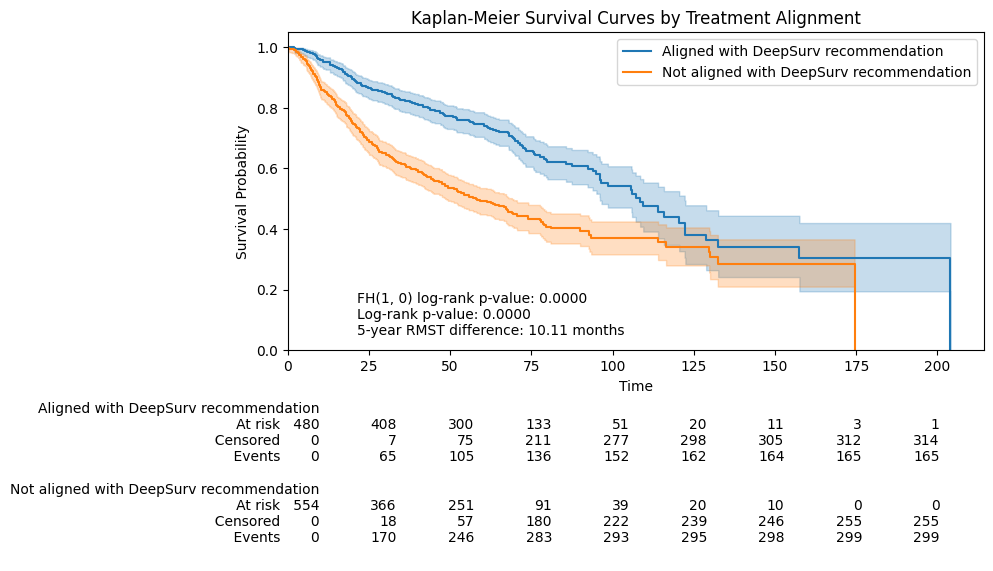

Delta (risk_treated - risk untreated) mean: -0.13644951581954956
Delta (risk_treated - risk untreated) standard deviation: 0.32057005167007446
Log-rank test p-value: 0.028160430983751414

[RMST by Treatment Recommendation]
RMST (aligned) at tau=60.00: 49.9267
RMST (not aligned) at tau=60.00: 44.9227
RMST difference (aligned - not aligned): 5.0040
Fleming-Harrington test p-value (p=1, q=0): 0.0218


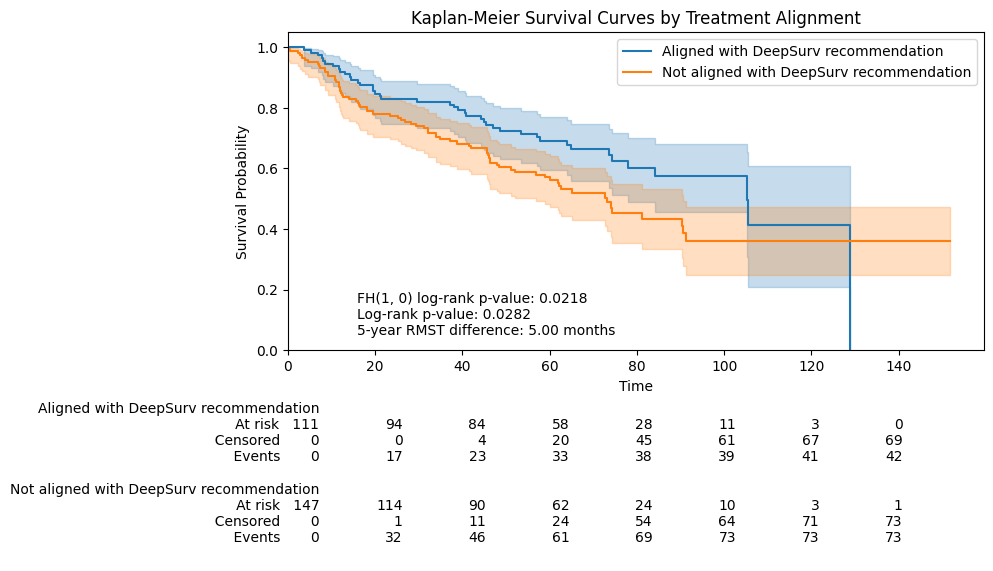

In [2]:
# ============================================================
# DeepSurv + Multi-Objective Optuna
# Objectives: Validation C-index (maximize) AND Validation RMST diff (maximize)
# - Deterministic bootstrap aggregation per trial (fixed bootstrap seeds)
# - Each trial refits on bootstrap-resampled TRAIN sets and scores on fixed VALID
# - Capacity budgets, conservative feature/param caps, column-dropout,
#   grouped L1 (stronger on interactions), and WD applied to last layer.
# - Final Kaplan–Meier uses RSF-style function adapted for DeepSurv.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# --------------------
# Imports
# --------------------
import os, math, warnings, random, gc, time, threading
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler

# Prefer torchsurv if available; fallback to custom Efron
try:
    from torchsurv.loss.cox import neg_partial_log_likelihood
    _HAS_TORCHSURV = True
except Exception:
    _HAS_TORCHSURV = False

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

import optuna
from optuna.samplers import NSGAIISampler

# Lifelines for RMST + KM
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import restricted_mean_survival_time

# Optional: dashboard
try:
    import portpicker
except Exception:
    portpicker = None

try:
    from google.colab import output as colab_output
except Exception:
    colab_output = None

warnings.filterwarnings("ignore", message="Ties in event time detected; using efron's method to handle ties.")

# Determinism
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# Cox losses
# ============================================================

def _cox_negloglik_efron(pred, event, time_vals):
    """Efron tie handling; pred is (N,1) or (N,)"""
    eta = pred.reshape(-1)
    e = event.to(torch.float32).reshape(-1)
    t = time_vals.reshape(-1)

    order = torch.argsort(t, descending=True)
    t = t[order]
    e = e[order]
    eta = eta[order]

    exp_eta = torch.exp(eta)
    cum_exp = torch.cumsum(exp_eta, dim=0)

    uniq_mask = torch.ones_like(t, dtype=torch.bool)
    uniq_mask[1:] = t[1:] != t[:-1]
    idxs = torch.nonzero(uniq_mask, as_tuple=False).reshape(-1)
    idxs = torch.cat([idxs, torch.tensor([len(t)], device=t.device)])

    nll = torch.tensor(0.0, device=t.device)
    eps = 1e-12

    for k in range(len(idxs) - 1):
        start, end = idxs[k].item(), idxs[k + 1].item()
        e_slice = e[start:end]
        d = int(e_slice.sum().item())
        if d == 0:
            continue
        eta_events = eta[start:end][e_slice.bool()]
        exp_events = torch.exp(eta[start:end])[e_slice.bool()]
        s_eta = eta_events.sum()
        risk_sum = cum_exp[end - 1]
        s_exp = exp_events.sum()

        log_terms = 0.0
        for j in range(d):
            log_terms = log_terms + torch.log(risk_sum - (j / d) * s_exp + eps)
        nll = nll - (s_eta - log_terms)

    return nll / t.numel()


def cox_negloglik(pred, event, time_vals):
    if _HAS_TORCHSURV:
        return neg_partial_log_likelihood(pred, event, time_vals, reduction='mean')
    return _cox_negloglik_efron(pred, event, time_vals)


def cox_negloglik_breslow_weighted(pred, event, time_vals, weight=None):
    """Weighted Breslow neg partial log-likelihood (IPTW)."""
    eta = pred.reshape(-1)
    e = event.to(torch.float32).reshape(-1)
    t = time_vals.reshape(-1)

    if weight is None:
        weight = torch.ones_like(eta)
    else:
        weight = weight.reshape(-1)

    order = torch.argsort(t, descending=True)
    t = t[order]
    e = e[order]
    eta = eta[order]
    w = weight[order]

    exp_eta = torch.exp(eta)
    w_exp = w * exp_eta
    cum_w_exp = torch.cumsum(w_exp, dim=0)

    uniq = torch.ones_like(t, dtype=torch.bool)
    uniq[1:] = t[1:] != t[:-1]
    idxs = torch.nonzero(uniq, as_tuple=False).reshape(-1)
    idxs = torch.cat([idxs, torch.tensor([len(t)], device=t.device)])

    nll = torch.tensor(0.0, device=t.device)
    eps = 1e-12

    for k in range(len(idxs) - 1):
        s, eidx = idxs[k].item(), idxs[k + 1].item()
        emask = e[s:eidx] > 0.5
        if emask.sum() == 0:
            continue
        w_events = w[s:eidx][emask]
        eta_events = eta[s:eidx][emask]
        s_eta = (w_events * eta_events).sum()
        denom = cum_w_exp[eidx - 1]
        nll = nll - (s_eta - w_events.sum() * torch.log(denom + eps))

    return nll / (w.sum() + 1e-9)


def cox_loss(pred, event, time_vals, weight=None):
    """Use weighted Breslow if weights provided; else Efron/torchsurv."""
    if weight is None:
        return cox_negloglik(pred, event, time_vals)
    return cox_negloglik_breslow_weighted(pred, event, time_vals, weight)

# ============================================================
# Model, dataset, sampler, utils
# ============================================================

class DeepSurvMLP(nn.Module):
    def __init__(self, in_features, hidden_layers, dropout=0.0, activation=nn.ReLU()):
        super().__init__()
        layers, d = [], in_features
        for units in hidden_layers:
            layers += [nn.Linear(d, units), activation]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = units
        layers.append(nn.Linear(d, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class SurvivalDataset(Dataset):
    def __init__(self, features, time_vals, events, weights=None):
        self.x = torch.tensor(features, dtype=torch.float32)
        self.time = torch.tensor(time_vals, dtype=torch.float32)
        self.event = torch.tensor(events.astype(bool), dtype=torch.bool)
        if weights is None:
            self.w = torch.ones(len(self.x), dtype=torch.float32)
        else:
            self.w = torch.tensor(weights, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.time[idx], self.event[idx], self.w[idx]


class EventBalancedBatchSampler(Sampler):
    """Ensure each batch has at least one event, if possible."""

    def __init__(self, events_numpy, batch_size, seed=42):
        events = np.asarray(events_numpy).astype(bool)
        self.pos_idx = np.where(events)[0]
        self.neg_idx = np.where(~events)[0]
        assert len(self.pos_idx) > 0, "No events in training set — cannot balance batches."
        self.bs = int(batch_size)
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        pos = self.rng.permutation(self.pos_idx)
        neg = self.rng.permutation(self.neg_idx)
        n_total = len(pos) + len(neg)
        n_batches = math.ceil(n_total / self.bs)
        pi = ni = 0
        for _ in range(n_batches):
            take_pos = 1 if pi < len(pos) else 0
            avail_neg = max(0, len(neg) - ni)
            take_neg = min(self.bs - take_pos, avail_neg)
            need = self.bs - (take_pos + take_neg)
            extra_pos = min(need, max(0, len(pos) - (pi + take_pos)))
            take_pos += extra_pos
            batch = np.concatenate([pos[pi:pi + take_pos], neg[ni:ni + take_neg]])
            pi += take_pos
            ni += take_neg
            if batch.size == 0:
                break
            self.rng.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return math.ceil((len(self.pos_idx) + len(self.neg_idx)) / self.bs)


def make_optimizer_groups(model, lr, wd, apply_final_wd=True):
    """AdamW with optional exclusion of last-layer weights from weight decay."""
    linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
    last_linear = linears[-1] if len(linears) > 0 else None

    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith('bias'):
            no_decay.append(p)
            continue
        if (last_linear is not None) and (p is last_linear.weight) and not apply_final_wd:
            no_decay.append(p)
            continue
        decay.append(p)

    return optim.AdamW(
        [{'params': decay, 'weight_decay': float(wd)},
         {'params': no_decay, 'weight_decay': 0.0}],
        lr=float(lr)
    )


def set_dropout_p(model, p):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.p = float(p)


def set_weight_decay(optimizer, wd):
    for g in optimizer.param_groups:
        g['weight_decay'] = float(wd)


def l1_penalty_first_layer(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            return m.weight.abs().sum()
    return torch.tensor(0.0, device=next(model.parameters()).device)


def l1_first_layer_grouped(model, inter_start_idx, lam_main=0.0, lam_inter=0.0):
    """Grouped L1: separate shrinkage for main vs interaction feature columns."""
    W = None
    for m in model.modules():
        if isinstance(m, nn.Linear):
            W = m.weight
            break
    if W is None or (lam_main == 0 and lam_inter == 0):
        return torch.tensor(0.0, device=next(model.parameters()).device)
    main_sum = W[:, :inter_start_idx].abs().sum()
    inter_sum = W[:, inter_start_idx:].abs().sum()
    return lam_main * main_sum + lam_inter * inter_sum


def column_dropout(x, p, col_start):
    """Drop whole columns from col_start onward with prob p (shared across batch)."""
    if p <= 0.0:
        return x
    keep = 1.0 - float(p)
    B, D = x.shape
    if col_start >= D:
        return x
    device_ = x.device
    m = torch.bernoulli(torch.full((D - col_start,), keep, device=device_)) / max(keep, 1e-6)
    x = x.clone()
    x[:, col_start:] = x[:, col_start:] * m
    return x


@torch.no_grad()
def evaluate_ci(model, dataloader, device_):
    model.eval()
    preds, times, events = [], [], []
    for batch in dataloader:
        if len(batch) == 4:
            x, t, e, _ = batch
        else:
            x, t, e = batch
        y = torch.clamp(model(x.to(device_)), -20, 20)
        preds.append(y.cpu().numpy().ravel())
        times.append(t.numpy())
        events.append(e.numpy())

    preds = np.concatenate(preds)
    times = np.concatenate(times)
    events = np.concatenate(events)
    if np.isnan(preds).any():
        return -np.inf
    return concordance_index_censored(events.astype(bool), times, preds)[0]


def evaluate_ci_grouped(model, X, t, e, group_mask):
    """Compute C-index within group_mask==1 and group_mask==0."""
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X, dtype=torch.float32, device=device)).cpu().numpy().ravel()
    res = {}
    for label, mask in [("ACT=1", group_mask.astype(bool)), ("ACT=0", ~group_mask.astype(bool))]:
        if mask.sum() >= 3:
            ci = concordance_index_censored(e[mask].astype(bool), t[mask], preds[mask])[0]
            res[label] = float(ci)
        else:
            res[label] = np.nan
    return res


@torch.no_grad()
def deepsurv_predict_risk(model, X_np, device_=None, batch_size=4096):
    """Predict risk scores (higher=worse) for a numpy feature matrix."""
    if device_ is None:
        device_ = device
    model.eval()
    X_np = np.asarray(X_np, dtype=np.float32)
    n = X_np.shape[0]
    out = np.empty((n,), dtype=np.float32)
    for s in range(0, n, int(batch_size)):
        e = min(n, s + int(batch_size))
        x = torch.tensor(X_np[s:e], dtype=torch.float32, device=device_)
        y = torch.clamp(model(x), -20, 20).detach().cpu().numpy().ravel()
        out[s:e] = y
    return out


def _apply_input_dropout(x, p):
    if p <= 0.0:
        return x
    keep = 1.0 - p
    mask = torch.bernoulli(torch.full_like(x, keep))
    return x * mask / max(keep, 1e-6)


def train_one_epoch_reg(
    model,
    optimizer,
    dataloader,
    device_,
    l1_lambda=0.0,
    epoch=0,
    warmup_epochs=20,
    input_dropout=0.0,
    noise_std=0.0,
    grad_clip=5.0,
    col_dropout_p=0.0,
    col_start=0,
    inter_start_idx=None,
    lam_main=0.0,
    lam_inter=0.0,
):
    model.train()
    warm = min(1.0, (epoch + 1) / float(warmup_epochs))
    loss_sum, w_sum = 0.0, 0.0

    for x, t, e, w in dataloader:
        if e.sum().item() == 0:
            continue

        x = x.to(device_)
        t = t.to(device_)
        e = e.to(device_)
        w = w.to(device_)

        if input_dropout > 0.0:
            x = _apply_input_dropout(x, input_dropout)
        if col_dropout_p > 0.0 and col_start > 0:
            x = column_dropout(x, col_dropout_p, col_start)
        if noise_std > 0.0:
            x = x + noise_std * torch.randn_like(x)

        optimizer.zero_grad(set_to_none=True)
        out = torch.clamp(model(x), -20, 20)
        loss = cox_loss(out, e, t, weight=w)

        if l1_lambda > 0:
            if inter_start_idx is None:
                loss = loss + (l1_lambda * warm) * l1_penalty_first_layer(model)
            else:
                loss = loss + (l1_lambda * warm) * l1_first_layer_grouped(
                    model,
                    inter_start_idx,
                    lam_main=lam_main,
                    lam_inter=lam_inter,
                )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
        optimizer.step()

        loss_sum += loss.item() * float(w.sum().item())
        w_sum += float(w.sum().item())

    return {'avg_loss': (loss_sum / max(w_sum, 1e-9)), 'warm': warm}


def full_risk_set_step_reg(
    model,
    optimizer,
    ds,
    device_,
    l1_lambda=0.0,
    warm=1.0,
    input_dropout=0.0,
    noise_std=0.0,
    grad_clip=5.0,
    col_dropout_p=0.0,
    col_start=0,
    inter_start_idx=None,
    lam_main=0.0,
    lam_inter=0.0,
):
    model.train()

    X_all = ds.x.to(device_)
    t_all = ds.time.to(device_)
    e_all = ds.event.to(device_)
    w_all = ds.w.to(device_)

    XX = X_all
    if input_dropout > 0.0:
        XX = _apply_input_dropout(XX, input_dropout)
    if col_dropout_p > 0.0 and col_start > 0:
        XX = column_dropout(XX, col_dropout_p, col_start)
    if noise_std > 0.0:
        XX = XX + noise_std * torch.randn_like(XX)

    optimizer.zero_grad(set_to_none=True)
    out_all = torch.clamp(model(XX), -20, 20)
    loss_full = cox_loss(out_all, e_all, t_all, weight=w_all)

    if l1_lambda > 0:
        if inter_start_idx is None:
            loss_full = loss_full + (l1_lambda * warm) * l1_penalty_first_layer(model)
        else:
            loss_full = loss_full + (l1_lambda * warm) * l1_first_layer_grouped(
                model,
                inter_start_idx,
                lam_main=lam_main,
                lam_inter=lam_inter,
            )

    loss_full.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
    optimizer.step()

    return float(loss_full.detach().cpu().item())


def count_params(in_dim, layers):
    params, d = 0, in_dim
    for h in layers:
        params += d * h + h
        d = h
    params += d * 1 + 1
    return int(params)

# ============================================================
# Data loading & preprocessing
# ============================================================

# ---------- Paths ----------
# Update these to your own locations if not using Drive/Colab.
TRAIN_CSV = "/content/drive/MyDrive/affyfRMATrain.csv"
VALID_CSV = "/content/drive/MyDrive/affyfRMAValidation.csv"
TEST_CSV  = "/content/drive/MyDrive/affyfRMATest.csv"

GENES_CSV = "/mnt/data/LOOCV_Genes2.csv"
if not os.path.exists(GENES_CSV):
    if os.path.exists("/content/LOOCV_Genes2.csv"):
        GENES_CSV = "/content/LOOCV_Genes2.csv"
    elif os.path.exists("/content/drive/MyDrive/LOOCV_Genes2.csv"):
        GENES_CSV = "/content/drive/MyDrive/LOOCV_Genes2.csv"
    elif os.path.exists("LOOCV_Genes2.csv"):
        GENES_CSV = "LOOCV_Genes2.csv"
print("LOOCV_Genes2.csv path:", GENES_CSV)

CLINICAL_VARS = [
    "Adjuvant Chemo", "Age", "IS_MALE",
    "Stage_IA", "Stage_IB", "Stage_II", "Stage_III",
    "Histology_Adenocarcinoma", "Histology_Large Cell Carcinoma", "Histology_Squamous Cell Carcinoma",
    "Race_African American", "Race_Asian", "Race_Caucasian", "Race_Native Hawaiian or Other Pacific Islander", "Race_Unknown",
    "Smoked?_No", "Smoked?_Unknown", "Smoked?_Yes",
]


def load_genes_list(genes_csv):
    g = pd.read_csv(genes_csv)
    if "Prop" not in g.columns or "Gene" not in g.columns:
        raise ValueError(f"LOOCV_Genes2.csv must have columns 'Gene' and 'Prop'. Found: {list(g.columns)}")
    g["Prop"] = pd.to_numeric(g["Prop"], errors="coerce").fillna(0)
    genes = g.loc[g["Prop"] == 1, "Gene"].astype(str).tolist()
    print(f"[Genes] Selected {len(genes)} genes with Prop == 1")
    return genes


def coerce_survival_cols(df, time_col="OS_MONTHS", event_col="OS_STATUS"):
    if df[event_col].dtype == object:
        df[event_col] = df[event_col].replace({"DECEASED": 1, "LIVING": 0, "Dead": 1, "Alive": 0}).astype(int)
    else:
        df[event_col] = pd.to_numeric(df[event_col], errors="coerce").fillna(0).astype(int)
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce").fillna(0.0).astype(float)
    return df


def coerce_act(df, act_col="Adjuvant Chemo"):
    if act_col not in df.columns:
        raise KeyError(f"Missing treatment column '{act_col}'.")
    if df[act_col].dtype == object:
        df[act_col] = df[act_col].replace({"OBS": 0, "ACT": 1}).astype(int)
    else:
        df[act_col] = pd.to_numeric(df[act_col], errors="coerce").fillna(0).astype(int)
    return df


def preprocess_split(df, clinical_vars, gene_names):
    df = df.copy()
    if "Adjuvant Chemo" in df.columns:
        df["Adjuvant Chemo"] = df["Adjuvant Chemo"].replace({"OBS": 0, "ACT": 1})

    for col in ["Adjuvant Chemo", "IS_MALE"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    df = coerce_survival_cols(df, time_col="OS_MONTHS", event_col="OS_STATUS")

    keep_cols = [c for c in clinical_vars if c in df.columns] + [g for g in gene_names if g in df.columns]
    missing_clin = [c for c in clinical_vars if c not in df.columns]
    if missing_clin:
        print(f"[WARN] Missing clinical columns: {missing_clin}")

    cols = ["OS_STATUS", "OS_MONTHS"] + keep_cols
    return df[cols].copy()


# Load CSVs
train_raw = pd.read_csv(TRAIN_CSV)
valid_raw = pd.read_csv(VALID_CSV)
test_raw  = pd.read_csv(TEST_CSV)

GENE_LIST = load_genes_list(GENES_CSV)

train_df = preprocess_split(train_raw, CLINICAL_VARS, GENE_LIST)
valid_df = preprocess_split(valid_raw, CLINICAL_VARS, GENE_LIST)
test_df  = preprocess_split(test_raw,  CLINICAL_VARS, GENE_LIST)

# Intersect features that exist everywhere
feat_candidates = [c for c in (CLINICAL_VARS + GENE_LIST)
                   if c in train_df.columns and c in valid_df.columns and c in test_df.columns]

CLIN_FEATS = [c for c in CLINICAL_VARS if c in feat_candidates]
GENE_FEATS = [g for g in GENE_LIST if g in feat_candidates]
CLIN_FEATS_PRETX = [c for c in CLIN_FEATS if c != "Adjuvant Chemo"]

print(f"[Features] Using {len(feat_candidates)} common features → Clinical={len(CLIN_FEATS)}, Genes={len(GENE_FEATS)}")

# Sort Train/Val by time/status
train_df = train_df.sort_values(by=["OS_MONTHS", "OS_STATUS"], ascending=[False, False]).reset_index(drop=True)
valid_df = valid_df.sort_values(by=["OS_MONTHS", "OS_STATUS"], ascending=[False, False]).reset_index(drop=True)


def rank_genes_univariate(train_df_, gene_cols):
    y = Surv.from_arrays(
        event=train_df_["OS_STATUS"].astype(bool).values,
        time=train_df_["OS_MONTHS"].values.astype(float),
    )
    ranks = []
    for g in gene_cols:
        Xg = train_df_[[g]].to_numpy(dtype=np.float32)
        try:
            model = CoxPHSurvivalAnalysis(alpha=1e-12)
            model.fit(Xg, y)
            pred = model.predict(Xg)
            ci = concordance_index_censored(y["event"], y["time"], pred)[0]
            ranks.append((g, float(ci)))
        except Exception:
            ranks.append((g, 0.5))
    ranks.sort(key=lambda z: z[1], reverse=True)
    return [g for g, _ in ranks]


GENE_RANK = rank_genes_univariate(train_df, GENE_FEATS)
MAX_GENES = len(GENE_RANK)
print(f"[Gene Ranking] Ranked {MAX_GENES} genes on TRAIN")

# ============================================================
# Feature construction (main effects + interactions) & IPTW
# ============================================================

def build_features_with_interactions(
    df,
    main_genes,
    inter_genes,
    act_col="Adjuvant Chemo",
    dup_inter=1,
    clin_cols=None,
    dtype=np.float32,
):
    """Build [clinical + main_genes + (inter_genes * ACT)] features.

    If dup_inter>1, duplicates interaction columns with unique names.
    """
    if clin_cols is None:
        clin_cols = CLIN_FEATS

    base_cols = list(clin_cols) + list(main_genes)
    X_base = df[base_cols].to_numpy(dtype=dtype)
    A = df[act_col].to_numpy(dtype=dtype).reshape(-1, 1)

    names = list(base_cols)
    blocks = [X_base]

    if len(inter_genes) > 0:
        X_int = df[list(inter_genes)].to_numpy(dtype=dtype) * A
        blocks.append(X_int)
        names += [f"{g}*ACT" for g in inter_genes]

        if int(dup_inter) > 1:
            for d in range(1, int(dup_inter)):
                blocks.append(X_int.copy())
                names += [f"{g}*ACT#dup{d}" for g in inter_genes]

    X = np.concatenate(blocks, axis=1) if len(blocks) > 1 else X_base
    return X, names


def compute_iptw(
    df,
    covariate_cols,
    act_col="Adjuvant Chemo",
    ps_clip=(0.05, 0.95),
    w_clip=(0.1, 10.0),
    ref_prevalence=None,
    model=None,
):
    A = df[act_col].astype(int).values
    X = df[covariate_cols].astype(float).values

    if model is None:
        model = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")
        model.fit(X, A)

    ps = model.predict_proba(X)[:, 1]
    ps = np.clip(ps, ps_clip[0], ps_clip[1])

    if ref_prevalence is None:
        ref_prevalence = A.mean()

    w = np.where(A == 1, ref_prevalence / ps, (1 - ref_prevalence) / (1 - ps))
    w = np.clip(w, w_clip[0], w_clip[1])
    return w.astype(np.float32), model, float(ref_prevalence)


def compute_alignment_rmst_diff_deepsurv(
    model,
    df,
    genes_main,
    genes_inter,
    dup_inter,
    clin_cols,
    med,
    scaler,
    tau=60,
    time_col="OS_MONTHS",
    event_col="OS_STATUS",
    act_col="Adjuvant Chemo",
    final = False
):
    """Compute RMST difference (aligned - not aligned) at tau months, no plots."""
    df = df.copy()
    df = coerce_act(df, act_col)
    df = coerce_survival_cols(df, time_col=time_col, event_col=event_col)

    df_treated = df.copy()
    df_treated[act_col] = 1

    df_untreated = df.copy()
    df_untreated[act_col] = 0

    X_treated_raw, _ = build_features_with_interactions(
        df_treated,
        genes_main,
        genes_inter,
        act_col=act_col,
        dup_inter=dup_inter,
        clin_cols=clin_cols,
        dtype=np.float32,
    )
    X_untreated_raw, _ = build_features_with_interactions(
        df_untreated,
        genes_main,
        genes_inter,
        act_col=act_col,
        dup_inter=dup_inter,
        clin_cols=clin_cols,
        dtype=np.float32,
    )

    X_treated = np.where(np.isnan(X_treated_raw), med, X_treated_raw)
    X_untreated = np.where(np.isnan(X_untreated_raw), med, X_untreated_raw)
    X_treated = scaler.transform(X_treated).astype(np.float32)
    X_untreated = scaler.transform(X_untreated).astype(np.float32)

    risk_treated = deepsurv_predict_risk(model, X_treated)
    risk_untreated = deepsurv_predict_risk(model, X_untreated)

    if final:
      delta = risk_treated - risk_untreated
      print(f"Final: Delta Mean {delta.mean()}\nDelta Standard Deviation: {delta.std()}")

    model_rec = np.where(risk_treated < risk_untreated, 1, 0)
    actual = df[act_col].to_numpy(int)
    alignment = actual == model_rec

    mask_aligned = alignment
    mask_not_aligned = ~alignment

    if int(mask_aligned.sum()) == 0 or int(mask_not_aligned.sum()) == 0:
        return 0.0

    kmf_aligned = KaplanMeierFitter()
    kmf_not_aligned = KaplanMeierFitter()

    kmf_aligned.fit(
        durations=df.loc[mask_aligned, time_col],
        event_observed=df.loc[mask_aligned, event_col],
    )
    kmf_not_aligned.fit(
        durations=df.loc[mask_not_aligned, time_col],
        event_observed=df.loc[mask_not_aligned, event_col],
    )

    rmst_aligned = float(restricted_mean_survival_time(kmf_aligned, t=tau))
    rmst_not_aligned = float(restricted_mean_survival_time(kmf_not_aligned, t=tau))
    return float(rmst_aligned - rmst_not_aligned)


# ============================================================
# Optuna: Multi-objective
#   maximize validation C-index AND maximize validation RMST diff
# ============================================================

ARCH_CHOICES = ("16", "32", "64", "32-16", "64-32", "64-64")


def layers_from_arch(arch_str: str):
    return [int(x) for x in arch_str.split("-") if x.strip()]


def suggest_hparams(trial):
    base_main = [16, 32, 64, 96, 128, 192, 256, 384, 512, 800, MAX_GENES]
    TOPK_MAIN_CHOICES = tuple(sorted({k for k in base_main if k <= MAX_GENES}))
    top_k_genes = trial.suggest_categorical("top_k_genes", TOPK_MAIN_CHOICES)

    # Keep explicit interactions off by default (as in your DeepSurv code)
    base_inter = [0, 8, 16, 32, 64]
    TOPK_INTER_CHOICES = tuple(sorted({k for k in base_inter if k <= MAX_GENES}))
    top_k_inter_raw = trial.suggest_categorical("top_k_inter", TOPK_INTER_CHOICES)

    arch = trial.suggest_categorical("arch", ARCH_CHOICES)
    dropout = trial.suggest_float("dropout", 0.10, 0.50)
    input_dropout = trial.suggest_float("input_dropout", 0.00, 0.15)
    noise_std = trial.suggest_float("noise_std", 0.0, 0.08)

    wd = trial.suggest_float("wd", 1e-6, 3e-3, log=True)
    use_l1 = trial.suggest_categorical("use_l1", (0, 1))
    l1 = 0.0 if use_l1 == 0 else trial.suggest_float("l1", 1e-7, 1e-3, log=True)

    lr = trial.suggest_float("lr", 1e-5, 4e-4, log=True)
    sched = trial.suggest_categorical("sched", ("cosine", "cawr", "none"))
    cawr_T0 = 32
    cawr_Tmult = 2
    if sched == "cawr":
        cawr_T0 = trial.suggest_int("cawr_T0", 16, 72, step=8)
        cawr_Tmult = trial.suggest_categorical("cawr_Tmult", (1, 2, 3))

    epochs = trial.suggest_int("epochs", 96, 256, step=32)
    batch_size = trial.suggest_categorical("batch_size", (32, 64, 128))
    grad_clip = trial.suggest_float("grad_clip", 2.0, 9.0)

    top_k_inter = int(min(int(top_k_inter_raw), int(top_k_genes)))

    return dict(
        arch=arch,
        top_k_genes=int(top_k_genes),
        top_k_inter=int(top_k_inter),
        dropout=float(dropout),
        input_dropout=float(input_dropout),
        noise_std=float(noise_std),
        wd=float(wd),
        use_l1=int(use_l1),
        l1=float(l1),
        lr=float(lr),
        sched=str(sched),
        cawr_T0=int(cawr_T0),
        cawr_Tmult=int(cawr_Tmult),
        epochs=int(epochs),
        batch_size=int(batch_size),
        grad_clip=float(grad_clip),
    )


# Warm-ups and caps
MAX_EPOCHS_CAP = 256
WARMUP_EPOCHS_L1 = 20
WARMUP_EPOCHS_DROPOUT = 20
WARMUP_EPOCHS_WD = 20
DROPOUT_START = 0.10
WD_START = 0.0

# Budgets tied to sample size
N_EVENTS_TR = int(train_df["OS_STATUS"].sum())
FEAT_EVENT_FRACTION = 0.50
FEAT_BUDGET = max(24, int(FEAT_EVENT_FRACTION * N_EVENTS_TR))  # total inputs incl. clinical
PARAM_BUDGET = 120_000

print(f"[Budgets] events(train)={N_EVENTS_TR} → feature budget≤{FEAT_BUDGET} total inputs, param budget≤{PARAM_BUDGET:,}")

# Column-dropout and grouped L1
COL_DROPOUT_P = 0.30
L1_LAM_MAIN = 0.2
L1_LAM_INTER = 1.0

# IPTW (train model, apply to val)
w_tr, ps_model, pi_tr = compute_iptw(train_df, covariate_cols=CLIN_FEATS_PRETX, act_col="Adjuvant Chemo")
w_va, _, _ = compute_iptw(
    valid_df,
    covariate_cols=CLIN_FEATS_PRETX,
    act_col="Adjuvant Chemo",
    ref_prevalence=pi_tr,
    model=ps_model,
)

# Bootstrap tuning on TRAIN; each fitted model is scored on the fixed VALID split.
BOOTSTRAP_TUNE_N = 5
BOOTSTRAP_BASE_SEED = 42
BOOTSTRAP_MAX_RESAMPLE_TRIES = 256


def seed_all(seed):
    seed = int(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


def bootstrap_resample_df(df, seed, require_two_arms=False, require_event=True):
    rng = np.random.default_rng(int(seed))
    n = len(df)
    for _ in range(BOOTSTRAP_MAX_RESAMPLE_TRIES):
        idx = rng.integers(0, n, size=n)
        boot = df.iloc[idx].copy()
        if require_event and int(boot["OS_STATUS"].sum()) == 0:
            continue
        if require_two_arms and boot["Adjuvant Chemo"].nunique() < 2:
            continue
        return boot.sort_values(by=["OS_MONTHS", "OS_STATUS"], ascending=[False, False]).reset_index(drop=True)
    raise RuntimeError("Could not draw a valid bootstrap sample with events and both treatment arms.")


def fit_bootstrap_deepsurv(
    hp,
    layers,
    train_boot_df,
    valid_eval_df,
    genes_main,
    genes_inter,
    dup_inter,
    seed,
):
    seed_all(seed)

    Xtr_raw, _ = build_features_with_interactions(
        train_boot_df,
        genes_main,
        genes_inter,
        act_col="Adjuvant Chemo",
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        dtype=np.float32,
    )
    Xva_raw, _ = build_features_with_interactions(
        valid_eval_df,
        genes_main,
        genes_inter,
        act_col="Adjuvant Chemo",
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        dtype=np.float32,
    )

    med = np.nanmedian(Xtr_raw, axis=0)
    Xtr = np.where(np.isnan(Xtr_raw), med, Xtr_raw)
    Xva = np.where(np.isnan(Xva_raw), med, Xva_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr).astype(np.float32)
    Xva = sc.transform(Xva).astype(np.float32)

    ytr_t = train_boot_df["OS_MONTHS"].to_numpy(np.float32)
    ytr_e = train_boot_df["OS_STATUS"].to_numpy(int)
    yva_t = valid_eval_df["OS_MONTHS"].to_numpy(np.float32)
    yva_e = valid_eval_df["OS_STATUS"].to_numpy(int)

    w_tr_boot, _, _ = compute_iptw(train_boot_df, covariate_cols=CLIN_FEATS_PRETX, act_col="Adjuvant Chemo")

    bs = int(hp["batch_size"])
    tr_ds = SurvivalDataset(Xtr, ytr_t, ytr_e, weights=w_tr_boot)
    va_ds = SurvivalDataset(Xva, yva_t, yva_e)

    tr_sampler = EventBalancedBatchSampler(ytr_e, bs, seed=seed)
    tr_loader = DataLoader(tr_ds, batch_sampler=tr_sampler, num_workers=0)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0)

    model = DeepSurvMLP(Xtr.shape[1], layers, dropout=float(hp["dropout"])).to(device)
    opt_ = make_optimizer_groups(model, lr=float(hp["lr"]), wd=float(hp["wd"]), apply_final_wd=True)

    epochs = int(min(hp["epochs"], MAX_EPOCHS_CAP))

    if hp["sched"] == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_, T_max=epochs)
        def sched_step(i): sched.step()
    elif hp["sched"] == "cawr":
        sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            opt_,
            T_0=int(hp["cawr_T0"]),
            T_mult=int(hp["cawr_Tmult"]),
        )
        def sched_step(i): sched.step(i + 1)
    else:
        sched = None
        def sched_step(i): return

    PATIENCE = 16
    MIN_DELTA = 1e-4
    no_improve = 0
    best_val_ci = -np.inf
    best_epoch = 0
    best_state = None

    col_start = len(CLIN_FEATS)
    inter_start_idx = len(CLIN_FEATS) + len(genes_main)

    for ep in range(epochs):
        frac_d = min(1.0, ep / float(WARMUP_EPOCHS_DROPOUT))
        frac_w = min(1.0, ep / float(WARMUP_EPOCHS_WD))
        set_dropout_p(model, DROPOUT_START + (float(hp['dropout']) - DROPOUT_START) * frac_d)
        set_weight_decay(opt_, WD_START + (float(hp['wd']) - WD_START) * frac_w)

        st = train_one_epoch_reg(
            model,
            opt_,
            tr_loader,
            device,
            l1_lambda=float(hp.get("l1", 0.0)),
            epoch=ep,
            warmup_epochs=WARMUP_EPOCHS_L1,
            input_dropout=float(hp.get("input_dropout", 0.0)),
            noise_std=float(hp.get("noise_std", 0.0)),
            grad_clip=float(hp.get("grad_clip", 5.0)),
            col_dropout_p=COL_DROPOUT_P,
            col_start=col_start,
            inter_start_idx=inter_start_idx if hp.get("use_l1", 0) == 1 else None,
            lam_main=L1_LAM_MAIN,
            lam_inter=L1_LAM_INTER,
        )

        _ = full_risk_set_step_reg(
            model,
            opt_,
            tr_ds,
            device,
            l1_lambda=float(hp.get("l1", 0.0)),
            warm=st['warm'],
            input_dropout=float(hp.get("input_dropout", 0.0)),
            noise_std=float(hp.get("noise_std", 0.0)),
            grad_clip=float(hp.get("grad_clip", 5.0)),
            col_dropout_p=COL_DROPOUT_P,
            col_start=col_start,
            inter_start_idx=inter_start_idx if hp.get("use_l1", 0) == 1 else None,
            lam_main=L1_LAM_MAIN,
            lam_inter=L1_LAM_INTER,
        )

        sched_step(ep)

        va_ci = float(evaluate_ci(model, va_loader, device))

        if va_ci > best_val_ci + MIN_DELTA:
            best_val_ci = va_ci
            best_epoch = ep + 1
            no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    rmst_diff = compute_alignment_rmst_diff_deepsurv(
        model,
        valid_eval_df,
        genes_main=genes_main,
        genes_inter=genes_inter,
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        med=med,
        scaler=sc,
        tau=60,
        time_col="OS_MONTHS",
        event_col="OS_STATUS",
        act_col="Adjuvant Chemo",
    )

    del model, opt_, sched, tr_loader, va_loader, tr_ds, va_ds
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return dict(
        val_ci=float(best_val_ci),
        rmst_diff=float(rmst_diff),
        best_epoch=int(best_epoch),
    )


def objective(trial):
    hp = suggest_hparams(trial)
    layers = layers_from_arch(hp["arch"])

    # Trial-specific features under budgets
    MAX_NONCLIN = max(8, FEAT_BUDGET - len(CLIN_FEATS))
    k_main = int(min(hp["top_k_genes"], MAX_NONCLIN))
    k_int = int(min(hp["top_k_inter"], k_main, MAX_NONCLIN - k_main))

    genes_main = GENE_RANK[:k_main]
    genes_inter = genes_main[:k_int]
    dup_inter = 1

    Xtr_raw, feat_names = build_features_with_interactions(
        train_df,
        genes_main,
        genes_inter,
        act_col="Adjuvant Chemo",
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        dtype=np.float32,
    )

    # If params exceed cap, shrink interactions first, then mains
    in_dim_trial = Xtr_raw.shape[1]
    while count_params(in_dim_trial, layers) > PARAM_BUDGET and (k_int > 0 or k_main > 8):
        if k_int > 0:
            k_int = max(0, k_int // 2)
        else:
            k_main = max(8, int(k_main * 0.8))

        genes_main = GENE_RANK[:k_main]
        genes_inter = genes_main[:min(k_int, k_main, MAX_NONCLIN - k_main)]

        Xtr_raw, feat_names = build_features_with_interactions(
            train_df,
            genes_main,
            genes_inter,
            act_col="Adjuvant Chemo",
            dup_inter=dup_inter,
            clin_cols=CLIN_FEATS,
            dtype=np.float32,
        )
        in_dim_trial = Xtr_raw.shape[1]

    boot_val_cis = []
    boot_rmst_diffs = []
    boot_best_epochs = []

    for b in range(BOOTSTRAP_TUNE_N):
        boot_seed = BOOTSTRAP_BASE_SEED + trial.number * 1000 + b
        boot_train_df = bootstrap_resample_df(
            train_df,
            seed=boot_seed,
            require_two_arms=True,
            require_event=True,
        )

        res = fit_bootstrap_deepsurv(
            hp=hp,
            layers=layers,
            train_boot_df=boot_train_df,
            valid_eval_df=valid_df,
            genes_main=genes_main,
            genes_inter=genes_inter,
            dup_inter=dup_inter,
            seed=boot_seed,
        )
        boot_val_cis.append(float(res["val_ci"]))
        boot_rmst_diffs.append(float(res["rmst_diff"]))
        boot_best_epochs.append(int(res["best_epoch"]))

    median_val_ci = float(np.median(boot_val_cis))
    median_rmst_diff = float(np.median(boot_rmst_diffs))
    val_ci_se = float(np.std(boot_val_cis, ddof=1)) if len(boot_val_cis) > 1 else 0.0
    rmst_iqr = float(np.percentile(boot_rmst_diffs, 75) - np.percentile(boot_rmst_diffs, 25)) if len(boot_rmst_diffs) > 1 else 0.0
    best_epoch_median = int(round(np.median(boot_best_epochs))) if boot_best_epochs else 0

    trial.set_user_attr("best_epoch", int(best_epoch_median))
    trial.set_user_attr("n_features", int(in_dim_trial))
    trial.set_user_attr("k_main", int(k_main))
    trial.set_user_attr("k_int", int(k_int))
    trial.set_user_attr("dup_inter", int(dup_inter))
    trial.set_user_attr("param_cnt", int(count_params(in_dim_trial, layers)))
    trial.set_user_attr("val_ci", float(median_val_ci))
    trial.set_user_attr("rmst_diff", float(median_rmst_diff))
    trial.set_user_attr("val_ci_boot_median", float(median_val_ci))
    trial.set_user_attr("val_ci_boot_se", float(val_ci_se))
    trial.set_user_attr("rmst_diff_boot_median", float(median_rmst_diff))
    trial.set_user_attr("rmst_diff_boot_iqr", float(rmst_iqr))
    trial.set_user_attr("bootstrap_n", int(BOOTSTRAP_TUNE_N))

    print(
        f"[Trial {trial.number:03d}] Boot Val CI median({BOOTSTRAP_TUNE_N})={median_val_ci:.4f} "
        f"(SE={val_ci_se:.4f}) | RMST diff median({BOOTSTRAP_TUNE_N})={median_rmst_diff:.4f} "
        f"(IQR={rmst_iqr:.4f}) | N_feats={in_dim_trial} | k_main={k_main} | k_int={k_int} | arch={hp['arch']}"
    )

    # Multi-objective: maximize bootstrapped Val CI and bootstrapped RMST diff
    return float(median_val_ci), float(median_rmst_diff)


# ---- Study ----
RUN_TAG = f"valci_rmst_multiobj_boot{BOOTSTRAP_TUNE_N}-v3"
storage = f"sqlite:///deepsurv_optuna_multiobj_boot{BOOTSTRAP_TUNE_N}_v3.db"
study_name = f"deepsurv_{RUN_TAG}_M{MAX_GENES}"

study = optuna.create_study(
    directions=["maximize", "maximize"],
    study_name=study_name,
    storage=storage,
    load_if_exists=True,
    sampler=NSGAIISampler(seed=42),
)

# ---- Optuna Dashboard (optional) ----
try:
    if portpicker is not None and colab_output is not None:
        from optuna_dashboard import run_server

        PORT = portpicker.pick_unused_port()

        def _start_dashboard():
            run_server(storage, host="0.0.0.0", port=PORT)

        t = threading.Thread(target=_start_dashboard, daemon=True)
        t.start()
        time.sleep(2)
        dash_url = colab_output.eval_js(f"google.colab.kernel.proxyPort({PORT}, {{'cache': false}})")
        print("Optuna Dashboard:", dash_url)
except Exception as ex:
    print("[Optuna Dashboard] Could not start dashboard automatically.", ex)

# ---- Optimize ----
N_TRIALS = 100
print(f"Starting multi-objective bootstrap optimization: {N_TRIALS} trials x {BOOTSTRAP_TUNE_N} bootstraps/trial")
study.optimize(objective, n_trials=N_TRIALS, gc_after_trial=True)

# ============================================================
# Multi-objective selection from Pareto front (RSF-style)
#   Choose a compromise trial maximizing normalized(CI)+normalized(RMST)
# ============================================================

candidates = [
    t for t in study.best_trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.values is not None
]

if not candidates:
    candidates = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE and t.values is not None
    ]

if not candidates:
    raise RuntimeError("No completed multi-objective trials found. Increase N_TRIALS and rerun.")

ci_vals = np.array([float(t.values[0]) for t in candidates], dtype=float)
rmst_vals = np.array([float(t.values[1]) for t in candidates], dtype=float)

ci_min, ci_max = float(ci_vals.min()), float(ci_vals.max())
rmst_min, rmst_max = float(rmst_vals.min()), float(rmst_vals.max())

def _norm(x, lo, hi):
    return 0.0 if hi <= lo else (x - lo) / (hi - lo)

scored = []
for t in candidates:
    ci = float(t.values[0])
    rmst = float(t.values[1])
    score = _norm(ci, ci_min, ci_max) + _norm(rmst, rmst_min, rmst_max)
    scored.append((score, t))

scored.sort(key=lambda z: z[0], reverse=True)
chosen = scored[0][1]

print(f"\n[Pareto] Candidates: {len(candidates)}")
print(f"[Pareto] Selected compromise trial #{chosen.number}")
print(f"[Pareto] Selected values: Boot median Val CI={float(chosen.values[0]):.4f}, Boot median RMST diff={float(chosen.values[1]):.4f}")
print("[Chosen Params]", chosen.params)
print(
    "[Chosen Attrs] k_main=%s k_int=%s n_features=%s params=%s best_epoch=%s ci_se=%s rmst_iqr=%s boot_n=%s" %
    (
        str(chosen.user_attrs.get("k_main")),
        str(chosen.user_attrs.get("k_int")),
        str(chosen.user_attrs.get("n_features")),
        str(chosen.user_attrs.get("param_cnt")),
        str(chosen.user_attrs.get("best_epoch")),
        str(chosen.user_attrs.get("val_ci_boot_se")),
        str(chosen.user_attrs.get("rmst_diff_boot_iqr")),
        str(chosen.user_attrs.get("bootstrap_n")),
    )
)

# ============================================================
# Final training on Train+Val with chosen hyperparams
# ============================================================

best_hp = dict(chosen.params)  # copy
best_layers = layers_from_arch(best_hp["arch"])

# Recompute k_main/k_int under budgets
MAX_NONCLIN = max(8, FEAT_BUDGET - len(CLIN_FEATS))
k_main = int(min(int(best_hp["top_k_genes"]), MAX_NONCLIN))
k_int = int(min(int(best_hp.get("top_k_inter", 0)), k_main, MAX_NONCLIN - k_main))

genes_main = GENE_RANK[:k_main]
genes_inter = genes_main[:k_int]
dup_inter = 1

# Assemble Train+Val & Test
trainval_df = pd.concat([train_df, valid_df], axis=0, ignore_index=True)
trainval_df = trainval_df.sort_values(by=["OS_MONTHS", "OS_STATUS"], ascending=[False, False]).reset_index(drop=True)

X_trv_raw, feat_names = build_features_with_interactions(
    trainval_df,
    genes_main,
    genes_inter,
    act_col="Adjuvant Chemo",
    dup_inter=dup_inter,
    clin_cols=CLIN_FEATS,
    dtype=np.float32,
)
X_te_raw, _ = build_features_with_interactions(
    test_df,
    genes_main,
    genes_inter,
    act_col="Adjuvant Chemo",
    dup_inter=dup_inter,
    clin_cols=CLIN_FEATS,
    dtype=np.float32,
)

# If params exceed cap, shrink further (interactions first)
in_dim_final = X_trv_raw.shape[1]
while count_params(in_dim_final, best_layers) > PARAM_BUDGET and (k_int > 0 or k_main > 8):
    if k_int > 0:
        k_int = max(0, k_int // 2)
    else:
        k_main = max(8, int(k_main * 0.8))

    genes_main = GENE_RANK[:k_main]
    genes_inter = genes_main[:min(k_int, k_main, MAX_NONCLIN - k_main)]

    X_trv_raw, feat_names = build_features_with_interactions(
        trainval_df,
        genes_main,
        genes_inter,
        act_col="Adjuvant Chemo",
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        dtype=np.float32,
    )
    X_te_raw, _ = build_features_with_interactions(
        test_df,
        genes_main,
        genes_inter,
        act_col="Adjuvant Chemo",
        dup_inter=dup_inter,
        clin_cols=CLIN_FEATS,
        dtype=np.float32,
    )
    in_dim_final = X_trv_raw.shape[1]

print(f"[Final] Using features: {len(CLIN_FEATS)} clinical + {k_main} genes (main) + {k_int} interactions")

# Impute + standardize on Train+Val; apply to Test
med_trv = np.nanmedian(X_trv_raw, axis=0)
X_trv = np.where(np.isnan(X_trv_raw), med_trv, X_trv_raw)
X_te = np.where(np.isnan(X_te_raw), med_trv, X_te_raw)

sc_trv = StandardScaler().fit(X_trv)
X_trv = sc_trv.transform(X_trv).astype(np.float32)
X_te = sc_trv.transform(X_te).astype(np.float32)

# Survival labels
y_trv_t = trainval_df["OS_MONTHS"].to_numpy(np.float32)
y_trv_e = trainval_df["OS_STATUS"].to_numpy(int)
y_te_t = test_df["OS_MONTHS"].to_numpy(np.float32)
y_te_e = test_df["OS_STATUS"].to_numpy(int)

# IPTW on Train+Val, apply to Test
w_trv, ps_model_fin, pi_fin = compute_iptw(trainval_df, covariate_cols=CLIN_FEATS_PRETX, act_col="Adjuvant Chemo")
w_te, _, _ = compute_iptw(
    test_df,
    covariate_cols=CLIN_FEATS_PRETX,
    act_col="Adjuvant Chemo",
    ref_prevalence=pi_fin,
    model=ps_model_fin,
)

# Loaders
bs_fin = int(best_hp["batch_size"])
ds_trv = SurvivalDataset(X_trv, y_trv_t, y_trv_e, weights=w_trv)
ds_te = SurvivalDataset(X_te, y_te_t, y_te_e, weights=w_te)

sam_trv = EventBalancedBatchSampler(y_trv_e, bs_fin, seed=42)
dl_trv = DataLoader(ds_trv, batch_sampler=sam_trv, num_workers=0)
dl_trv_eval = DataLoader(ds_trv, batch_size=bs_fin, shuffle=False, num_workers=0)
dl_te = DataLoader(ds_te, batch_size=bs_fin, shuffle=False, num_workers=0)

# Model / optimizer / scheduler
model_final = DeepSurvMLP(in_dim_final, best_layers, dropout=float(best_hp["dropout"])).to(device)
opt_final = make_optimizer_groups(
    model_final,
    lr=float(best_hp["lr"]),
    wd=float(best_hp["wd"]),
    apply_final_wd=True,
)

epochs_fin = int(min(int(best_hp["epochs"]), MAX_EPOCHS_CAP))

if best_hp["sched"] == "cosine":
    sched_final = torch.optim.lr_scheduler.CosineAnnealingLR(opt_final, T_max=epochs_fin)
    def sched_step_final(i): sched_final.step()
elif best_hp["sched"] == "cawr":
    T0 = int(best_hp.get("cawr_T0", 32))
    Tmult = int(best_hp.get("cawr_Tmult", 2))
    sched_final = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_final, T_0=T0, T_mult=Tmult)
    def sched_step_final(i): sched_final.step(i + 1)
else:
    sched_final = None
    def sched_step_final(i): return

# Indices for regularizers/dropout
col_start_final = len(CLIN_FEATS)
inter_start_idx_final = len(CLIN_FEATS) + k_main

# Train with mild ES on Train+Val CI
PATIENCE_FIN = 16
MIN_DELTA = 1e-4
no_improve = 0
best_trv_ci = -np.inf
best_state = None

for ep in range(epochs_fin):
    frac_d = min(1.0, ep / float(WARMUP_EPOCHS_DROPOUT))
    frac_w = min(1.0, ep / float(WARMUP_EPOCHS_WD))
    set_dropout_p(model_final, DROPOUT_START + (float(best_hp['dropout']) - DROPOUT_START) * frac_d)
    set_weight_decay(opt_final, WD_START + (float(best_hp['wd']) - WD_START) * frac_w)

    st = train_one_epoch_reg(
        model_final,
        opt_final,
        dl_trv,
        device,
        l1_lambda=float(best_hp.get("l1", 0.0)),
        epoch=ep,
        warmup_epochs=WARMUP_EPOCHS_L1,
        input_dropout=float(best_hp.get("input_dropout", 0.0)),
        noise_std=float(best_hp.get("noise_std", 0.0)),
        grad_clip=float(best_hp.get("grad_clip", 5.0)),
        col_dropout_p=COL_DROPOUT_P,
        col_start=col_start_final,
        inter_start_idx=inter_start_idx_final if int(best_hp.get("use_l1", 0)) == 1 else None,
        lam_main=L1_LAM_MAIN,
        lam_inter=L1_LAM_INTER,
    )

    _ = full_risk_set_step_reg(
        model_final,
        opt_final,
        ds_trv,
        device,
        l1_lambda=float(best_hp.get("l1", 0.0)),
        warm=st['warm'],
        input_dropout=float(best_hp.get("input_dropout", 0.0)),
        noise_std=float(best_hp.get("noise_std", 0.0)),
        grad_clip=float(best_hp.get("grad_clip", 5.0)),
        col_dropout_p=COL_DROPOUT_P,
        col_start=col_start_final,
        inter_start_idx=inter_start_idx_final if int(best_hp.get("use_l1", 0)) == 1 else None,
        lam_main=L1_LAM_MAIN,
        lam_inter=L1_LAM_INTER,
    )

    sched_step_final(ep)

    trv_ci_now = float(evaluate_ci(model_final, dl_trv_eval, device))
    if trv_ci_now > best_trv_ci + MIN_DELTA:
        best_trv_ci = trv_ci_now
        no_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_final.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE_FIN:
            break

if best_state is not None:
    model_final.load_state_dict(best_state)

# Evaluate
trainval_ci = float(evaluate_ci(model_final, dl_trv_eval, device))
test_ci = float(evaluate_ci(model_final, dl_te, device))
print(f"\n[Final] Train+Val CI: {trainval_ci:.4f}")
print(f"[Final] Test CI:      {test_ci:.4f}")

# Per-arm C-indices (sanity)
act_trv = trainval_df["Adjuvant Chemo"].to_numpy(int)
act_te = test_df["Adjuvant Chemo"].to_numpy(int)
trv_grouped = evaluate_ci_grouped(model_final, X_trv, y_trv_t, y_trv_e, act_trv == 1)
te_grouped = evaluate_ci_grouped(model_final, X_te, y_te_t, y_te_e, act_te == 1)
print("[Train+Val] CI by arm:", trv_grouped)
print("[Test]      CI by arm:", te_grouped)

# Save artifacts
OUT_DIR = "/content/drive/MyDrive/deepsurv_optuna_multiobj_out"
os.makedirs(OUT_DIR, exist_ok=True)

torch.save(model_final.state_dict(), os.path.join(OUT_DIR, "deepsurv_best.pt"))
with open(os.path.join(OUT_DIR, "chosen_trial.txt"), "w") as f:
    f.write(f"trial_number={chosen.number}\n")
    f.write(f"values={chosen.values}\n")

with open(os.path.join(OUT_DIR, "chosen_params.txt"), "w") as f:
    f.write(str(best_hp))

with open(os.path.join(OUT_DIR, "features_used.txt"), "w") as f:
    f.write("\n".join(feat_names))

# Save preprocessing artifacts for inference
np.save(os.path.join(OUT_DIR, "median_impute.npy"), med_trv)
try:
    import joblib
    joblib.dump(sc_trv, os.path.join(OUT_DIR, "scaler.joblib"))
except Exception:
    pass

print("Saved final model and parameters to:", OUT_DIR)

# ============================================================
# Final Kaplan–Meier by alignment with DeepSurv recommendation
# (RSF-style function adapted for DeepSurv)
# ============================================================

def compare_treatment_recommendation_km_deepsurv(
    model,
    df,
    genes_main,
    genes_inter,
    dup_inter,
    clin_cols,
    med,
    scaler,
    time_col="OS_MONTHS",
    event_col="OS_STATUS",
    act_col="Adjuvant Chemo",
    path="",
    includeRMST=False,
    p=None,
    q=None,
    tau=60,
):
    """KM comparison for alignment with model's treatment recommendation on provided data."""

    df = df.copy()
    df = coerce_act(df, act_col)
    df = coerce_survival_cols(df, time_col=time_col, event_col=event_col)
    df[act_col] = df[act_col].astype(int)

    # Counterfactual feature matrices with ACT forced to 1 vs 0
    df_treated = df.copy()
    df_treated[act_col] = 1

    df_untreated = df.copy()
    df_untreated[act_col] = 0

    X_treated_raw, _ = build_features_with_interactions(
        df_treated,
        genes_main,
        genes_inter,
        act_col=act_col,
        dup_inter=dup_inter,
        clin_cols=clin_cols,
        dtype=np.float32,
    )
    X_untreated_raw, _ = build_features_with_interactions(
        df_untreated,
        genes_main,
        genes_inter,
        act_col=act_col,
        dup_inter=dup_inter,
        clin_cols=clin_cols,
        dtype=np.float32,
    )

    # Apply train-time imputation + scaling
    X_treated = np.where(np.isnan(X_treated_raw), med, X_treated_raw)
    X_untreated = np.where(np.isnan(X_untreated_raw), med, X_untreated_raw)
    X_treated = scaler.transform(X_treated).astype(np.float32)
    X_untreated = scaler.transform(X_untreated).astype(np.float32)

    # DeepSurv output is a risk score: higher = worse
    risk_treated = deepsurv_predict_risk(model, X_treated)
    risk_untreated = deepsurv_predict_risk(model, X_untreated)

    delta = risk_treated - risk_untreated
    print(f"Delta (risk_treated - risk untreated) mean: {delta.mean()}")
    print(f"Delta (risk_treated - risk untreated) standard deviation: {delta.std()}")

    model_rec = np.where(risk_treated < risk_untreated, 1, 0)  # choose lower risk arm
    actual = df[act_col].to_numpy(int)
    alignment = actual == model_rec

    df["model_rec"] = model_rec
    df["alignment"] = alignment

    mask_aligned = df["alignment"]
    mask_not_aligned = ~df["alignment"]

    kmf_aligned = KaplanMeierFitter()
    kmf_not_aligned = KaplanMeierFitter()

    plt.figure(figsize=(10, 6))

    kmf_aligned.fit(
        durations=df.loc[mask_aligned, time_col],
        event_observed=df.loc[mask_aligned, event_col],
        label="Aligned with DeepSurv recommendation",
    )
    ax = kmf_aligned.plot(ci_show=True)

    kmf_not_aligned.fit(
        durations=df.loc[mask_not_aligned, time_col],
        event_observed=df.loc[mask_not_aligned, event_col],
        label="Not aligned with DeepSurv recommendation",
    )
    kmf_not_aligned.plot(ax=ax, ci_show=True)

    results = logrank_test(
        df.loc[mask_aligned, time_col],
        df.loc[mask_not_aligned, time_col],
        event_observed_A=df.loc[mask_aligned, event_col],
        event_observed_B=df.loc[mask_not_aligned, event_col],
    )

    rmst_aligned = float(restricted_mean_survival_time(kmf_aligned, t=tau))
    rmst_not_aligned = float(restricted_mean_survival_time(kmf_not_aligned, t=tau))
    rmst_diff = rmst_aligned - rmst_not_aligned

    print("Log-rank test p-value:", results.p_value)

    print("\n[RMST by Treatment Recommendation]")
    print(f"RMST (aligned) at tau={tau:.2f}: {rmst_aligned:.4f}")
    print(f"RMST (not aligned) at tau={tau:.2f}: {rmst_not_aligned:.4f}")
    print(f"RMST difference (aligned - not aligned): {rmst_diff:.4f}")

    plt.title("Kaplan-Meier Survival Curves by Treatment Alignment")
    plt.xlabel("Time")
    plt.ylabel("Survival Probability")
    add_at_risk_counts(kmf_aligned, kmf_not_aligned)

    plt.text(0.1, 0.1, f"Log-rank p-value: {results.p_value:.4f}", transform=plt.gca().transAxes)

    if includeRMST:
        plt.text(0.1, 0.05, f"5-year RMST difference: {rmst_diff:.2f} months", transform=plt.gca().transAxes)

    if p is not None and q is not None:
        fh_results = logrank_test(
            df.loc[mask_aligned, time_col],
            df.loc[mask_not_aligned, time_col],
            event_observed_A=df.loc[mask_aligned, event_col],
            event_observed_B=df.loc[mask_not_aligned, event_col],
            weightings="fleming-harrington",
            p=p,
            q=q,
        )
        print(f"Fleming-Harrington test p-value (p={p}, q={q}): {fh_results.p_value:.4f}")
        plt.text(0.1, 0.15, f"FH({p}, {q}) log-rank p-value: {fh_results.p_value:.4f}", transform=plt.gca().transAxes)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(path + "km_alignment_deepsurv_recommendation.png", dpi=600)
    plt.show(block=False)

    return {
        "tau": float(tau),
        "rmst_aligned": float(rmst_aligned),
        "rmst_not_aligned": float(rmst_not_aligned),
        "rmst_diff": float(rmst_diff),
        "n_aligned": int(mask_aligned.sum()),
        "n_not_aligned": int(mask_not_aligned.sum()),
        "logrank_pvalue": float(results.p_value),
    }


# ---------------------------
# Kaplan–Meier (final): aligned vs not aligned
#   includeRMST=True, p=1, q=0 (as requested)
# ---------------------------

_ = compare_treatment_recommendation_km_deepsurv(
    model_final,
    trainval_df,
    genes_main=genes_main,
    genes_inter=genes_inter,
    dup_inter=dup_inter,
    clin_cols=CLIN_FEATS,
    med=med_trv,
    scaler=sc_trv,
    time_col="OS_MONTHS",
    event_col="OS_STATUS",
    act_col="Adjuvant Chemo",
    path=os.path.join(OUT_DIR, "trainval_"),
    includeRMST=True,
    p=1,
    q=0,
)

_ = compare_treatment_recommendation_km_deepsurv(
    model_final,
    test_df,
    genes_main=genes_main,
    genes_inter=genes_inter,
    dup_inter=dup_inter,
    clin_cols=CLIN_FEATS,
    med=med_trv,
    scaler=sc_trv,
    time_col="OS_MONTHS",
    event_col="OS_STATUS",
    act_col="Adjuvant Chemo",
    path=os.path.join(OUT_DIR, "test_"),
    includeRMST=True,
    p=1,
    q=0,
)